## Customer Segmentation & Churn Pattern Analytics

### Step 1 — Data Ingestion & Validation
Goal

Load the dataset and check if the data is valid and consistent.

#### Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#sns.set_style("whitegrid")

#### Load Data Set & Preview 

In [2]:
df = pd.read_csv(r"C:\Users\smitp\Desktop\Unifed Mentor LTD\Customer Segmentation Project\Dataset\European_Bank.csv")
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


#### Check Dataset Shape

In [3]:
df.shape

(10000, 14)

#### Data Types

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


#### Missing Values

In [5]:
df.isnull().sum()

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

#### Check Binary Columns 
HasCrCard

IsActiveMember

Exited

In [6]:
df["Exited"].value_counts()
df["HasCrCard"].value_counts()
df["IsActiveMember"].value_counts()

1    5151
0    4849
Name: IsActiveMember, dtype: int64

#### Validate Churn Target

In [7]:
(df["Exited"].value_counts(normalize=True) * 100).round(2).astype(str) + "%"

0    79.63%
1    20.37%
Name: Exited, dtype: object

### Step 2 — Data Cleaning & Preparation
Goal

Prepare the dataset for analysis.

#### Remove Non-Analytical Columns

In [8]:
df = df.drop(["CustomerId", "Surname"], axis=1)

#### Convert Categories

In [9]:
df["Gender"] = df["Gender"].astype("category")
df["Geography"] = df["Geography"].astype("category")

#### Create Age Groups

In [10]:
bins = [18,30,45,60,100]

labels = ["<30","30-45","46-60","60+"]

df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)

#### Credit Score Bands

In [11]:
bins = [300,580,700,850]

labels = ["Low","Medium","High"]

df["CreditBand"] = pd.cut(df["CreditScore"], bins=bins, labels=labels)

#### Tenure Groups

In [12]:
bins = [-1,3,7,10]

labels = ["New","Mid-term","Long-term"]

df["TenureGroup"] = pd.cut(df["Tenure"], bins=bins, labels=labels)

#### Balance Segments

In [13]:
df["BalanceSegment"] = "Zero Balance"

df.loc[df["Balance"] > 0, "BalanceSegment"] = pd.qcut(
    df.loc[df["Balance"] > 0, "Balance"],
    q=3,
    labels=["Low Balance", "Medium Balance", "High Balance"]
)

In [14]:
df.head()

,Year,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,CreditBand,TenureGroup,BalanceSegment
0,2025,619,France,Female,42,2,0.00,1,1,1,101348.88,1,30-45,Medium,New,Zero Balance
1,2025,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,30-45,Medium,New,Low Balance
2,2025,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,30-45,Low,Long-term,High Balance
3,2025,699,France,Female,39,1,0.00,2,0,0,93826.63,0,30-45,Medium,New,Zero Balance
4,2025,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,30-45,High,New,Medium Balance


#### Cleaned Dataset:

In [15]:
df.to_csv("cleaned_data_European_Bank.csv", index=False)

### Step 3 — Customer Segmentation Design
We now explore customer segments.

#### Geographic Segmentation

In [16]:
geo_churn = (df.groupby("Geography")["Exited"].mean() * 100).round(2).astype(str) + "%"

geo_churn

Geography
France     16.15%
Germany    32.44%
Spain      16.67%
Name: Exited, dtype: object

Text(0.5, 1.0, 'Churn Rate by Geography')

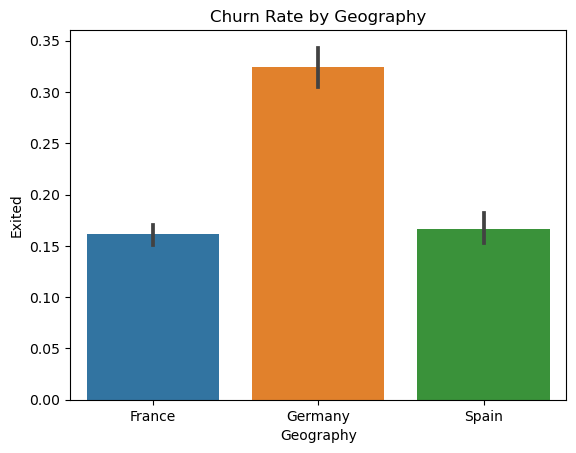

In [17]:
sns.barplot(x="Geography", y="Exited", data=df)
plt.title("Churn Rate by Geography")

#### Age Segmentation

In [18]:
age_churn = df.groupby("AgeGroup")["Exited"].mean()

<AxesSubplot:xlabel='AgeGroup', ylabel='Exited'>

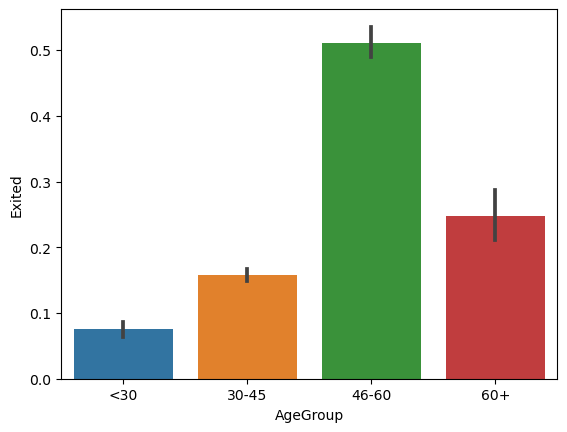

In [19]:
sns.barplot(x="AgeGroup", y="Exited", data=df)

#### Credit Score Segmentation

In [20]:
credit_churn = df.groupby("CreditBand")["Exited"].mean()

#### Tenure Segmentation

In [21]:
tenure_churn = df.groupby("TenureGroup")["Exited"].mean()

#### Balance Segmentation

In [22]:
balance_churn = df.groupby("BalanceSegment")["Exited"].mean()

### Step 4 — Churn Distribution Analysis

#### Overall Churn Rate

In [23]:
overall_churn = df["Exited"].mean()*100
print("Overall Churn Rate:", overall_churn)

Overall Churn Rate: 20.369999999999997


#### Segment-wise Churn

In [24]:
(df.groupby("NumOfProducts")["Exited"].mean() * 100).round(2).astype(str) + "%"

NumOfProducts
1    27.71%
2     7.58%
3    82.71%
4    100.0%
Name: Exited, dtype: object

#### Product vs Churn

Text(0.5, 1.0, 'Churn by Product Count')

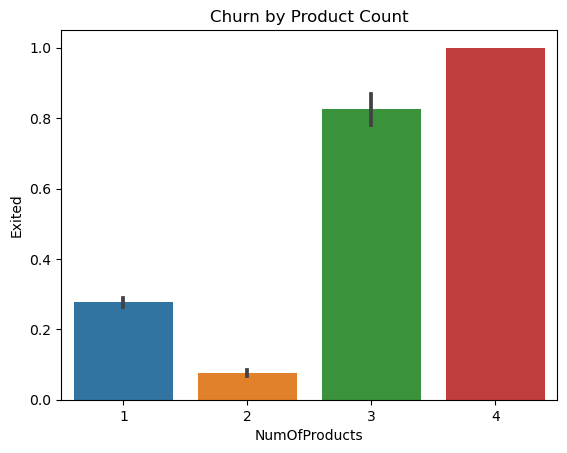

In [25]:
sns.barplot(x="NumOfProducts", y="Exited", data=df)
plt.title("Churn by Product Count")

### Step 5 — Comparative Demographic Analysis

#### Gender vs Churn

In [26]:
(df.groupby("Gender")["Exited"].mean() * 100).round(2).astype(str) + "%"

Gender
Female    25.07%
Male      16.46%
Name: Exited, dtype: object

<AxesSubplot:xlabel='Gender', ylabel='Exited'>

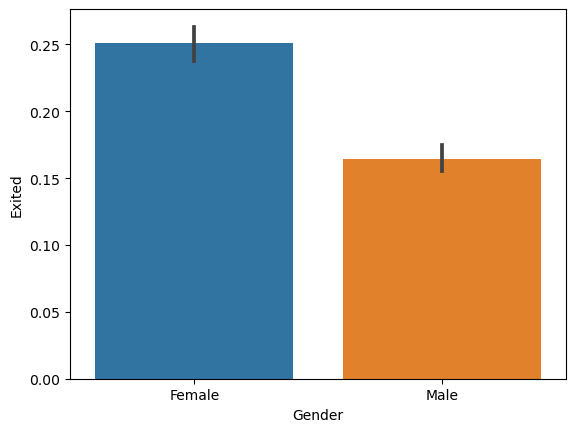

In [27]:
sns.barplot(x="Gender", y="Exited", data=df)

#### Geography + Age Interaction

In [28]:
pd.crosstab(
    df["AgeGroup"],
    df["Geography"],
    values=df["Exited"],
    aggfunc="mean"
)

Geography,France,Germany,Spain
AgeGroup,,,
<30,0.048685,0.125280,0.084746
30-45,0.123498,0.260930,0.125337
46-60,0.457944,0.673307,0.406566
60+,0.199134,0.389381,0.208333


<AxesSubplot:xlabel='Geography', ylabel='AgeGroup'>

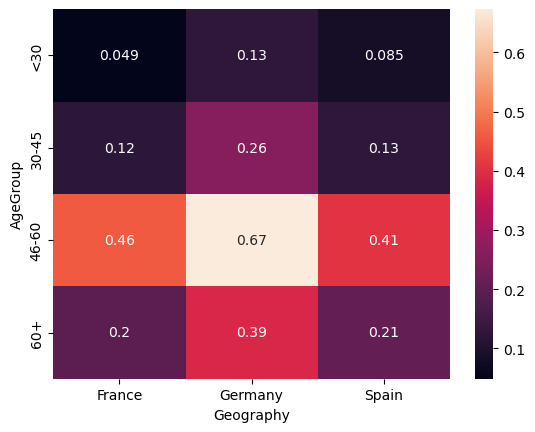

In [29]:
sns.heatmap(
    pd.crosstab(df["AgeGroup"], df["Geography"], values=df["Exited"], aggfunc="mean"),
    annot=True
)

#### Salary vs Churn

<AxesSubplot:xlabel='Exited', ylabel='EstimatedSalary'>

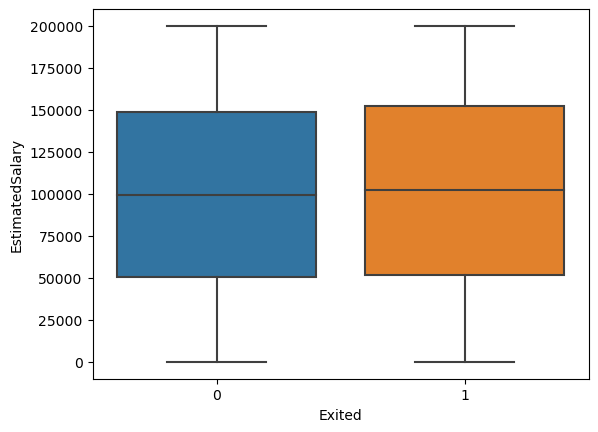

In [30]:
sns.boxplot(x="Exited", y="EstimatedSalary", data=df)

### Step 6 — High-Value Customer Churn Analysis
Define High Value Customers

Example rule:

Balance > 100000

#### Create High Value Flag

In [31]:
df["HighValueCustomer"] = df["Balance"] > 100000

#### High Value Churn Rate

In [32]:
(df.groupby("HighValueCustomer")["Exited"].mean() * 100).round(2).astype(str) + "%"

HighValueCustomer
False    15.88%
True     25.23%
Name: Exited, dtype: object

#### Salary vs Balance Comparison

<AxesSubplot:xlabel='EstimatedSalary', ylabel='Balance'>

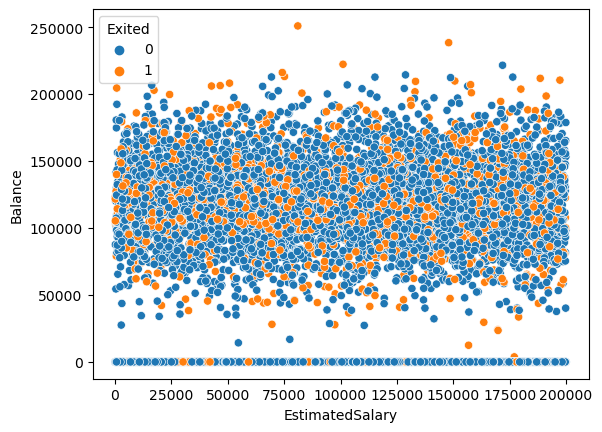

In [33]:
sns.scatterplot(
    x="EstimatedSalary",
    y="Balance",
    hue="Exited",
    data=df
)